# Computational Tools for Climate Science - Project 2026
---
**Group 2 - Chaac**

Authors: *Abiyo Gladys, Alex Blackmer, Caroline Roper, Han Nguyen, Negli Gallardo, Sheila Aguilar Palpa*

Date: *July 13-24th*

---

This project explores the relationship between precipitation and crop production in Southeast Asia. Specifically, we tie the Standardized Precipitation Index (SPI) derived from Climate Hazards Group InfraRed Precipitation with Station data (CHIRPS) with cereal production yield anomalies sourced from the Food and Agriculture Organization (FAO). This study considers two domains in Southeast Asia; the mainland (Monsoon Climate Region - MCR) and maritime (Equatorial Climate Region - ECR), focusing on the countries of Vietnam and Indonesia respectively.

In [1]:
# Install packages not included in base environment
!pip install cartopy
!pip install gdown
!pip install xclim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 384.7/384.7 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.1/196.1 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.8/80.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 5.2 MB/s eta 0:00:00


In [2]:
# Imports
import os
# Scientific data packages
import numpy as np
import scipy.signal
import xarray as xr
import pandas as pd
import datetime
# Plotting libraries
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import seaborn as sns
# Climate index package
import xclim
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import pearsonr

# Research Scope

In [3]:
ANALYSIS_PERIOD = ['1981', '2023']
countries = ['Indonesia', 'Viet Nam']

---
# Data Preparation
## Mount Google Drive
First step is to mount the Google Drive fonder containing group project data

In [4]:
# Mount Google Drive project data path
from google.colab import drive
drive.mount('/content/drive')
path_gd =  "/content/drive/MyDrive/Group Project Folder/Data/"
#  path_gd = '/content/drive/MyDrive/Group Project Folder/Data/'

Mounted at /content/drive


## Downloading data
This is a helper function for downloading data

---

In [5]:
import tempfile
import pooch
def pooch_load(filelocation=None, filename=None, processor=None):
    shared_location = './data'  # This is where we want to store the data
    user_temp_cache = tempfile.gettempdir()
    # Ensure the shared_location directory exists
    os.makedirs(shared_location, exist_ok=True)
    target_path = os.path.join(shared_location, filename)
    if os.path.exists(target_path):
        file = target_path
    else:
        # Download the file directly to the shared_location
        # Explicitly specify 'path' to ensure it goes to ./data and not the hidden cache
        file = pooch.retrieve(
            filelocation,
            known_hash=None,
            path=shared_location,
            fname=filename,
            processor=processor
        )
    return file

### Download CHIRPS data

In [6]:
# # code to retrieve and load the data
# chirps_path = 'https://data.chc.ucsb.edu/products/CHIRPS/v3.0/monthly/global/netcdf/chirps-v3.0.monthly.nc'

# # Extract filename from the URL
# chirps_filename = os.path.basename(chirps_path)

# pooch_load(chirps_path, filename=chirps_filename)
# #### open data via xarray
# chirps_data = xr.open_mfdataset(
#     pooch_load(chirps_path, filename=chirps_filename), combine="by_coords"
# )  # open the files as one dataset
# chirps_data

---
## Load Datasets
This section loads the country masks, precipitation, and cereal production data used for analysis

### Precipitation

In [7]:
precip_ds = xr.open_dataset(path_gd+ "chirps_sel.nc").sel(time=slice(*ANALYSIS_PERIOD))
precip_ds

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 516, latitude: 900, longitude: 1200)
Coordinates:
  * time       (time) datetime64[ns] 4kB 1981-01-01 1981-02-01 ... 2023-12-01
  * latitude   (latitude) float32 4kB -19.98 -19.92 -19.88 ... 24.88 24.92 24.97
  * longitude  (longitude) float32 5kB 90.02 90.08 90.12 ... 149.9 149.9 150.0
Data variables:
    precip     (time, latitude, longitude) float32 2GB ...
Attributes: (12/14)
    Conventions:       CF-1.6
    title:             CHIRPS Version 3.0
    history:           created by Climate Hazards Center
    version:           Version 3.0
    data_created:      2026-07-14
    creator_name:      Pete Peterson
    ...                ...
    documentation:     http://pubs.usgs.gov/ds/832/
    reference:         Funk, C.C., Peterson, P.J., Landsfeld, M.F., Pedreros,...
    acknowledgements:  The Climate Hazards Center InfraRed Precipitation with...
    ftp_url:           ftp://chg-ftpout.geog.ucsb.edu/pub/chg/products/CHIRPS...
    website:           http://chg.geog.ucsb.edu/data/chirps/index.html
    faq:               http://chg-wiki.geog.ucsb.edu/wiki/CHIRPS_FAQ

### Country Mask

In [8]:
country_mask = xr.open_dataset(path_gd + 'CountryMask/NetCDF/CountryMergedNC.nc')
country_mask = country_mask.rename({"lat": "latitude", "lon": "longitude"})

country_mask = country_mask["country_mask"].interp(
    latitude=precip_ds.latitude,
    longitude=precip_ds.longitude,
    method="nearest"
)

Text(0.5, 1.0, 'Country Mask')

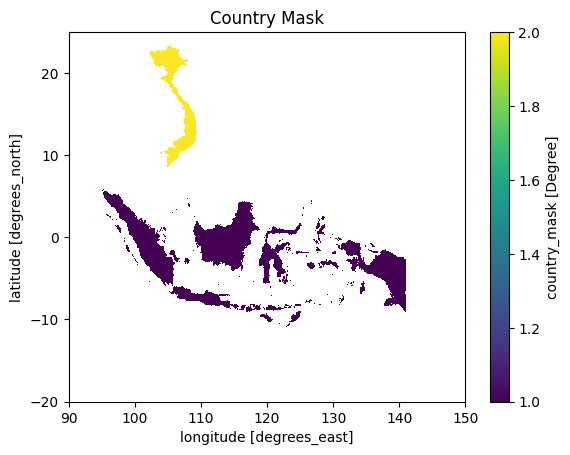

In [9]:
country_mask.plot()
plt.title("Country Mask")

### Cereal Production

In [10]:
cereal_df = pd.read_csv(path_gd + "data_cereal_land.csv", header=0, skiprows=4)
# Filter columns based on ANALYSIS_PERIOD
years = [str(year) for year in range(int(ANALYSIS_PERIOD[0]), int(ANALYSIS_PERIOD[1]) + 1)]
columns_to_keep = ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'] + years
existing_columns = [col for col in columns_to_keep if col in cereal_df.columns]
cereal_df = cereal_df[existing_columns]
cereal_df

,Country Name,Country Code,Indicator Name,Indicator Code,1981,1982,1983,1984,1985,1986,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Aruba,ABW,Cereal production (metric tons),AG.PRD.CREL.MT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Cereal production (metric tons),AG.PRD.CREL.MT,45003485.0,36230066.0,31916865.0,30257205.0,39232395.0,40580615.0,...,90908480.87,80958057.09,83981022.00,95401249.04,97221042.42,92193844.75,1.041884e+08,1.057639e+08,1.054980e+08,1.060342e+08
2,Afghanistan,AFG,Cereal production (metric tons),AG.PRD.CREL.MT,3893000.0,3724000.0,3591000.0,3418000.0,3242000.0,3084000.0,...,7012523.28,6010288.00,5708330.42,5059633.97,4304555.50,5771861.00,6.241828e+06,4.970923e+06,4.802495e+06,5.402975e+06
3,Africa Western and Central,AFW,Cereal production (metric tons),AG.PRD.CREL.MT,18865515.0,19099220.0,18897609.0,20745222.0,24933077.0,27936922.0,...,64659189.50,66767715.15,70577009.09,70883085.45,76247113.92,77387263.40,7.818291e+07,7.629473e+07,8.187634e+07,8.086655e+07
4,Angola,AGO,Cereal production (metric tons),AG.PRD.CREL.MT,316000.0,315000.0,337000.0,321000.0,308000.0,341400.0,...,1825128.76,2021290.68,2372602.15,2483183.07,2871952.31,2918493.21,3.077110e+06,3.059537e+06,3.179113e+06,3.335449e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,Kosovo,XKX,Cereal production (metric tons),AG.PRD.CREL.MT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
261,"Yemen, Rep.",YEM,Cereal production (metric tons),AG.PRD.CREL.MT,924710.0,862400.0,471096.0,480408.0,446285.0,700358.0,...,699962.00,459246.00,357068.00,358355.00,344648.00,456714.00,7.895270e+05,8.793415e+05,4.450000e+05,4.350000e+05
262,South Africa,ZAF,Cereal production (metric tons),AG.PRD.CREL.MT,18004771.0,11762871.0,6673572.0,7927492.0,11062037.0,11691051.0,...,16617348.61,12581802.08,10629626.27,19591509.64,15565749.67,13872311.88,1.879041e+07,1.923235e+07,1.803698e+07,1.901653e+07
263,Zambia,ZMB,Cereal production (metric tons),AG.PRD.CREL.MT,1050738.0,797960.0,982959.0,924702.0,1192709.0,1318756.0,...,3652300.93,2900164.12,3110868.43,3895117.44,2602942.73,2225768.76,3.689518e+06,3.953632e+06,3.056715e+06,3.658966e+06


### Population Data (REMOVE)



In [11]:
# pop_df = pd.read_csv(path_gd + 'population_estimations_WorldBank.csv', skiprows=4, sep=';')

# countries_pop = ['Indonesia', 'Viet Nam']
# columns_to_keep = ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'] + years

# pop_df_filtered = pop_df[pop_df['Country Name'].isin(countries_pop)]
# pop_df_filtered = pop_df_filtered[columns_to_keep]

# pop_df = pop_df_filtered.copy() # Assign the filtered DataFrame back to pop_df
# pop_df

---
## Precipitation

#### Subset by Country

In [12]:
# Mask each contry area and drop the NaNs
precip_ind = precip_ds.precip.where(country_mask == 1, drop=True)
precip_viet = precip_ds.precip.where(country_mask == 2, drop=True)

In [13]:
# Country boundaries for plotting
shpfilename = shpreader.natural_earth(resolution='50m', category='cultural', name='admin_0_countries')
reader = shpreader.Reader(shpfilename)
# Plotting function
def plot_precip_map(da_slice, title, country_code=None, cmap='Blues', vmax=1000, step=50, cbar_orient='vertical'):
    """
    Plots precipitation data on a map with optional country-specific borders.

    Args:
        da_slice: xarray.DataArray (single time step)
        title: Plot title string
        cmap: Colormap name
        country_code: 'VNM' for Vietnam, 'IDN' for Indonesia, or None for all.
        step: Increment for discrete color levels.
        cbar_orient: 'vertical' or 'horizontal'
    """
    # max_val = float(da_slice.max())
    levels = np.arange(0, vmax + step, step)

    fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})

    # Set background color to light gray
    ax.set_facecolor('#f0f0f0')

    # Setup colorbar orientation
    cbar_kwargs = {'label': 'Precipitation (mm)', 'ticks': levels, 'orientation': cbar_orient}

    im = da_slice.plot(ax=ax, cmap=cmap, transform=ccrs.PlateCarree(),
                       levels=levels, add_colorbar=True,
                       cbar_kwargs=cbar_kwargs)

    # Add ocean/coastline borders
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)

    # Add country borders
    if country_code:
        shpfilename = shpreader.natural_earth(resolution='50m', category='cultural', name='admin_0_countries')
        local_reader = shpreader.Reader(shpfilename)
        geom = [country.geometry for country in local_reader.records() if country.attributes['ADM0_A3'] == country_code]
        ax.add_geometries(geom, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='black', linestyle='-')
    else:
        ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black', alpha=0.8)

    # Fix: Access .values to prevent xarray/numpy dimension mismatch
    lons = da_slice.longitude.values
    lats = da_slice.latitude.values

    ax.set_xticks(np.linspace(lons.min(), lons.max(), 5), crs=ccrs.PlateCarree())
    ax.set_yticks(np.linspace(lats.min(), lats.max(), 5), crs=ccrs.PlateCarree())

    ax.xaxis.set_major_formatter(LongitudeFormatter(number_format='.0f', degree_symbol=''))
    ax.yaxis.set_major_formatter(LatitudeFormatter(number_format='.0f', degree_symbol=''))

    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(title)
    ax.minorticks_on()
    ax.set_aspect('equal')
    plt.show()

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_countries.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


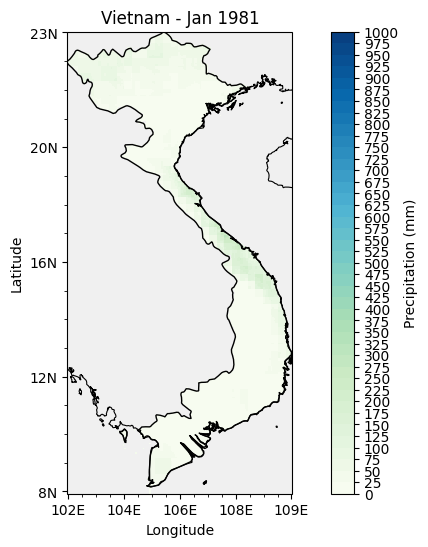

In [14]:
# Example usage for Vietnam
plot_precip_map(precip_viet.isel(time=0), "Vietnam - Jan 1981", cmap='GnBu', country_code='VNM', step=25)


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


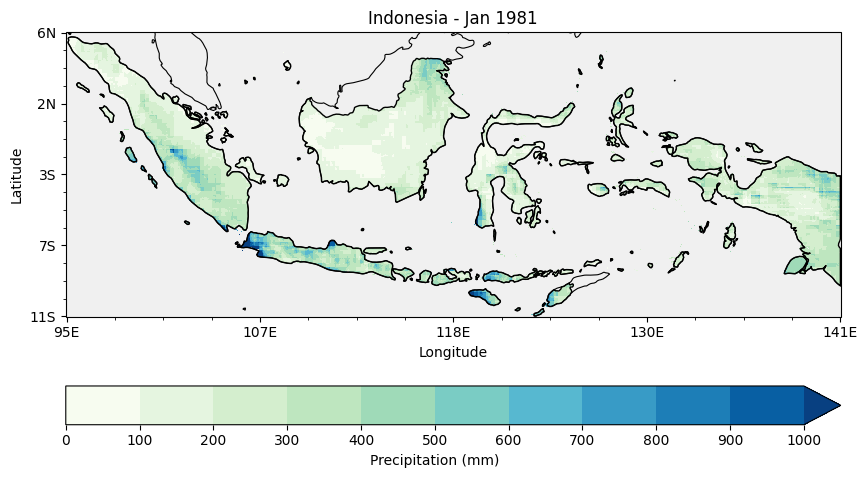

In [15]:
plot_precip_map(precip_ind.isel(time=0), "Indonesia - Jan 1981", cmap='GnBu', country_code='IDN', step=100, cbar_orient='horizontal')


### Climatologies

In [16]:
# Calculate average annual precipitation climatology (sum over months, mean over years)
precip_clim_ind = precip_ind.resample(time="YE").sum(dim="time", min_count=1).mean(dim="time")
precip_clim_viet = precip_viet.resample(time="YE").sum(dim="time", min_count=1).mean(dim="time")

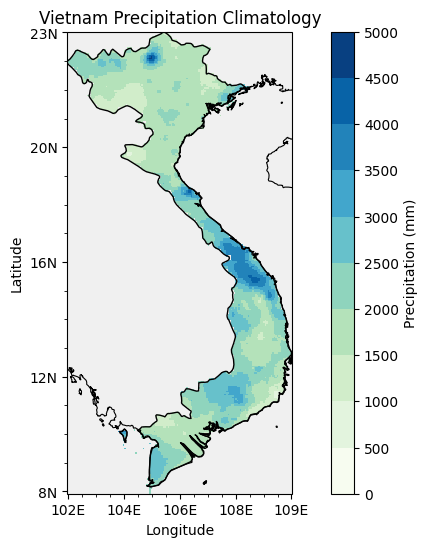

In [17]:
plot_precip_map(precip_clim_viet, "Vietnam Precipitation Climatology", cmap='GnBu', vmax=5000, country_code='VNM', step=500)


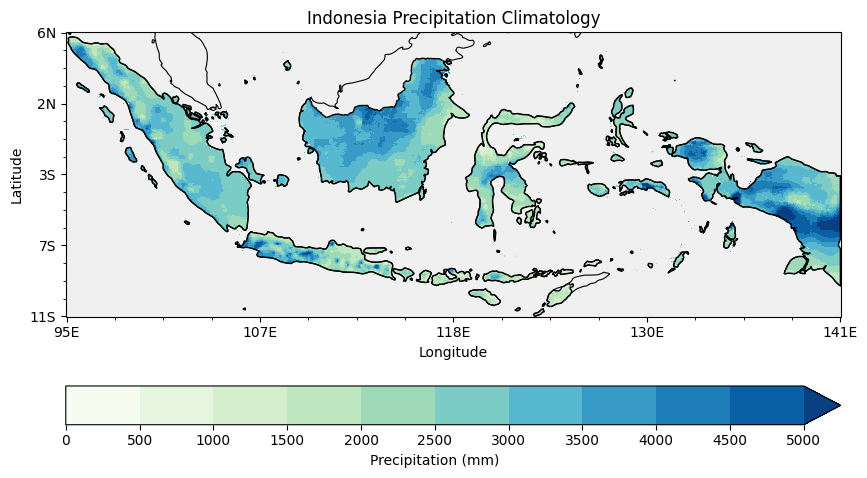

In [18]:
plot_precip_map(precip_clim_ind, "Indonesia Precipitation Climatology", cmap='GnBu', country_code='IDN', vmax=5000, step=500, cbar_orient='horizontal')


### SPI
Standardized precipitation index is calculated individually for Vietnam and Indonesia, and then used to classify drought severity by the following scheme:
 * Mild: 0 < SPI < -0.99
 * Severe: SPI > 1

 *Note: Severe includes categories of Moderate, Severe, and Extreme in classical definiton*

#### Vietnam

In [19]:
precip_viet_1d = precip_viet.mean(dim=["latitude", "longitude"])
spi_1m_viet = xclim.indicators.atmos.standardized_precipitation_index(pr=precip_viet_1d, freq='MS', window=1)
spi_6m_viet = xclim.indicators.atmos.standardized_precipitation_index(pr=precip_viet_1d, freq='MS', window=6)
spi_12m_viet = xclim.indicators.atmos.standardized_precipitation_index(pr=precip_viet_1d, freq='MS', window=12)

/usr/local/lib/python3.12/dist-packages/xclim/core/cfchecks.py:77: UserWarning: Variable does not have a `cell_methods` attribute.
  _check_cell_methods(getattr(vardata, "cell_methods", None), data["cell_methods"])
/usr/local/lib/python3.12/dist-packages/xclim/core/cfchecks.py:79: UserWarning: Variable has a non-conforming standard_name: Got `convective precipitation rate`, expected `['precipitation_flux']`
  check_valid(vardata, "standard_name", data["standard_name"])
/usr/local/lib/python3.12/dist-packages/xclim/core/cfchecks.py:77: UserWarning: Variable does not have a `cell_methods` attribute.
  _check_cell_methods(getattr(vardata, "cell_methods", None), data["cell_methods"])
/usr/local/lib/python3.12/dist-packages/xclim/core/cfchecks.py:79: UserWarning: Variable has a non-conforming standard_name: Got `convective precipitation rate`, expected `['precipitation_flux']`
  check_valid(vardata, "standard_name", data["standard_name"])
/usr/local/lib/python3.12/dist-packages/xclim/core/c

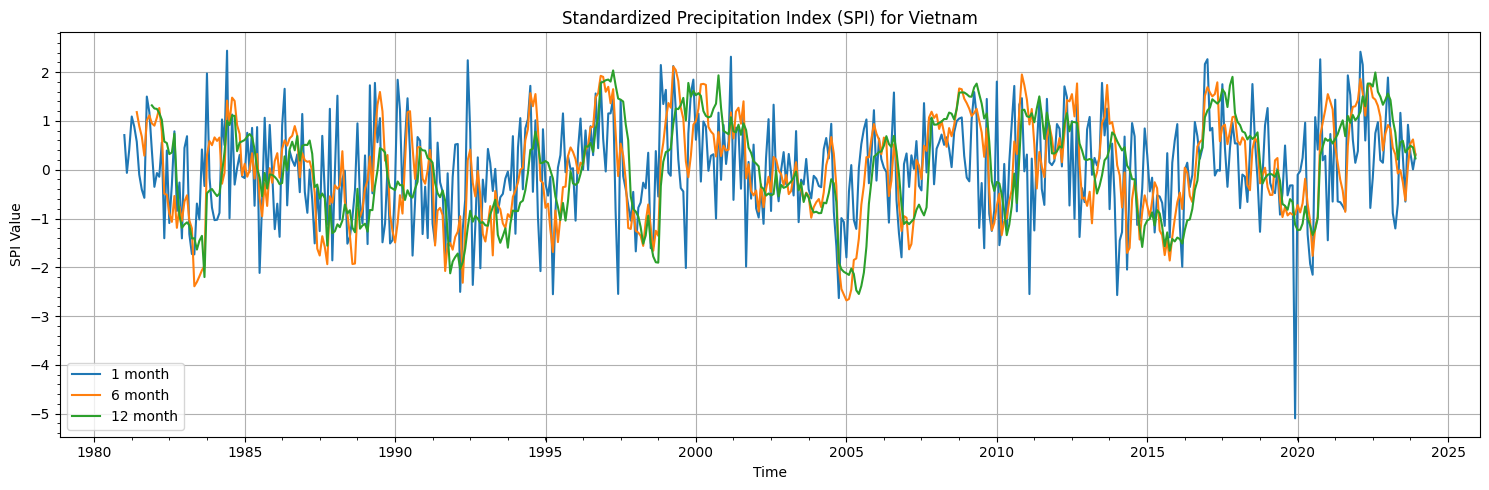

In [20]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(spi_1m_viet['time'], spi_1m_viet, label='1 month')
ax.plot(spi_6m_viet['time'], spi_6m_viet, label='6 month')
ax.plot(spi_12m_viet['time'], spi_12m_viet, label='12 month')

ax.legend()
ax.set_title('Standardized Precipitation Index (SPI) for Vietnam')
ax.set_xlabel('Time')
ax.set_ylabel('SPI Value')
ax.minorticks_on()
plt.grid(True)
plt.tight_layout()
plt.show()

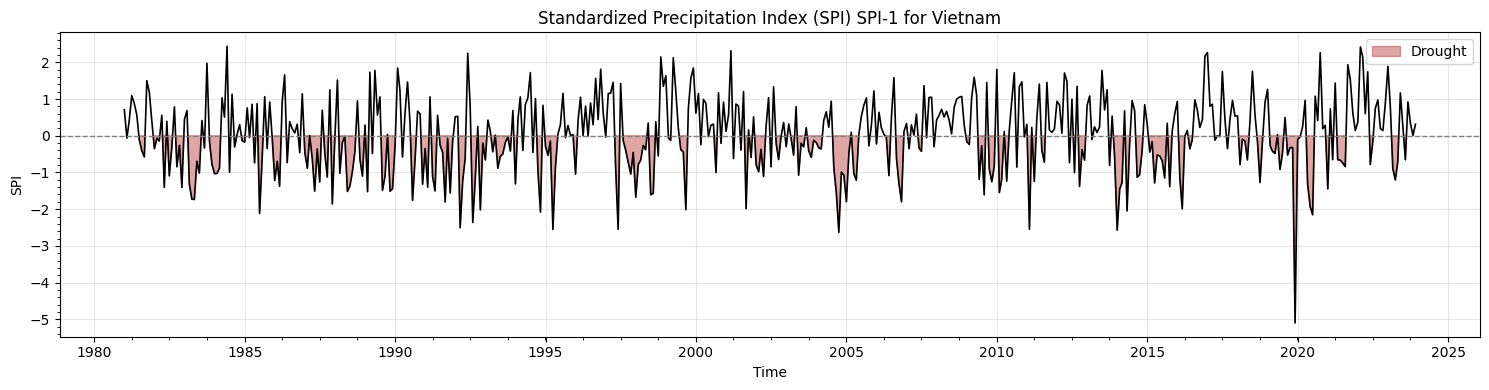

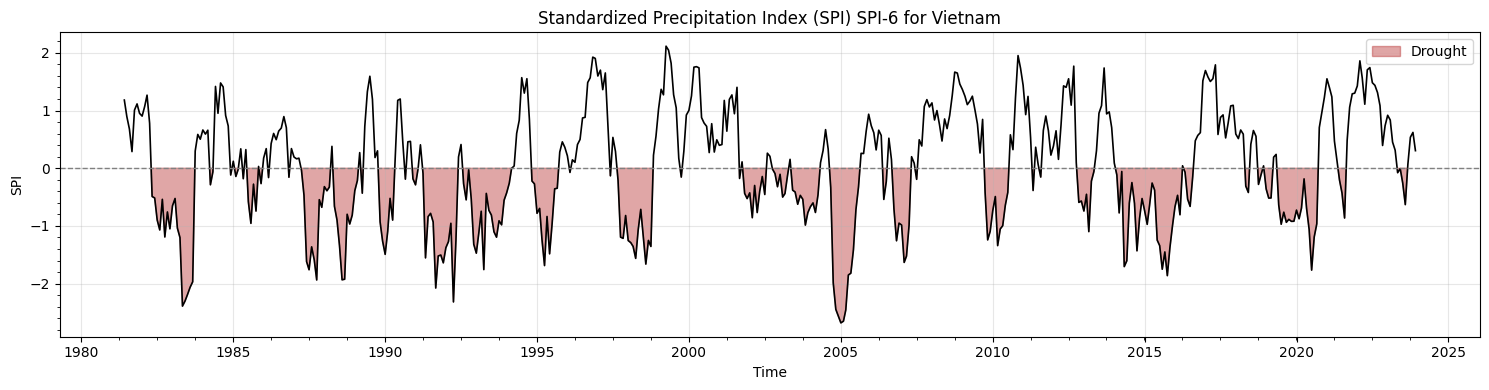

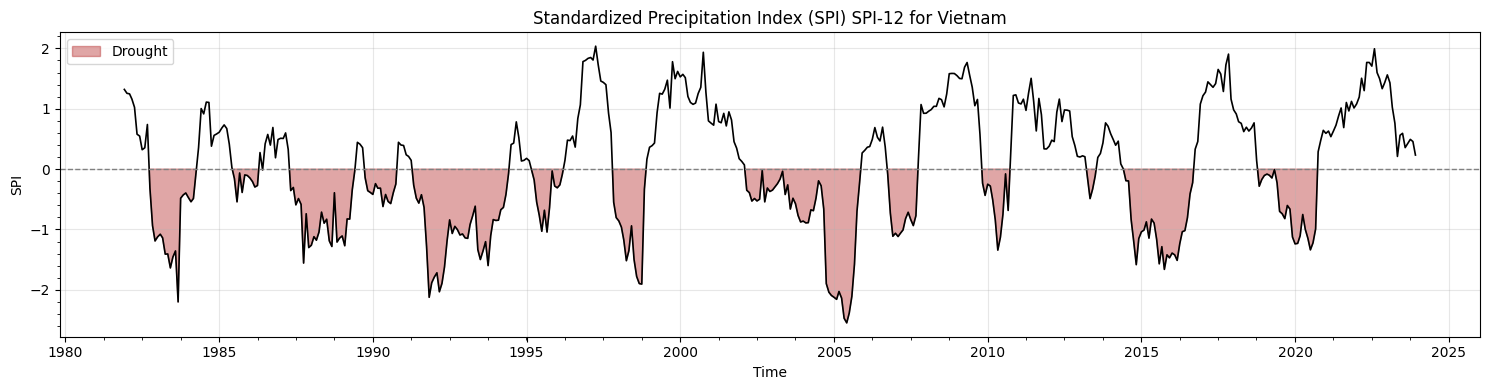

In [21]:
def plot_spi_drought(spi, title):
    fig, ax = plt.subplots(figsize=(15,4))

    # Serie SPI
    ax.plot(spi.time, spi, color='black', linewidth=1.2)

    # Línea de referencia
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)

    # Sombrear sequía (SPI < 0)
    ax.fill_between(
        spi.time,
        spi,
        0,
        where=(spi < 0),
        interpolate=True,
        color='firebrick',
        alpha=0.4,
        label='Drought'
    )

    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel("SPI")
    ax.grid(True, alpha=0.3)
    ax.minorticks_on()
    ax.legend()
    plt.tight_layout()
    plt.show()

# Graficar cada escala
plot_spi_drought(spi_1m_viet, "Standardized Precipitation Index (SPI) SPI-1 for Vietnam")
plot_spi_drought(spi_6m_viet, "Standardized Precipitation Index (SPI) SPI-6 for Vietnam")
plot_spi_drought(spi_12m_viet, "Standardized Precipitation Index (SPI) SPI-12 for Vietnam")

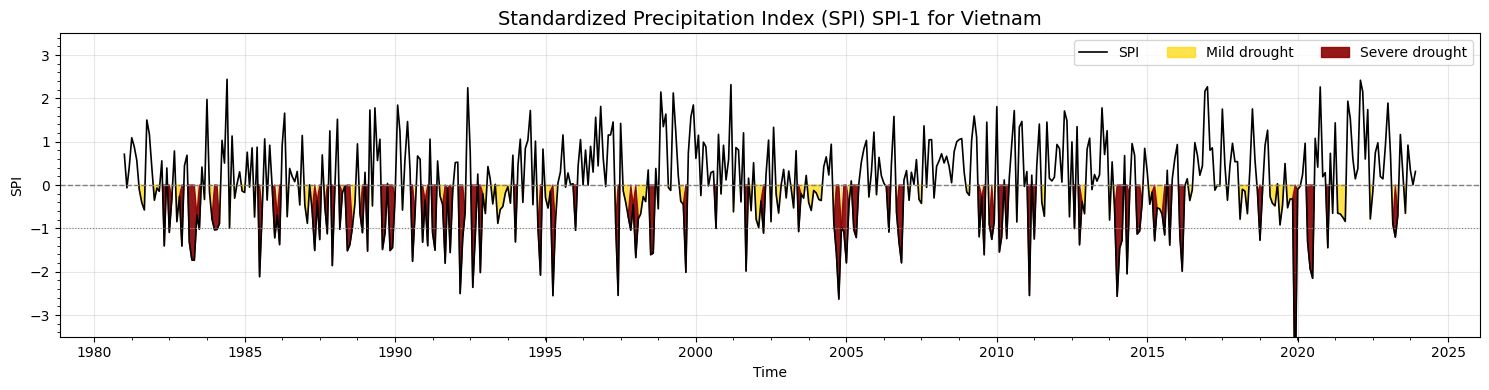

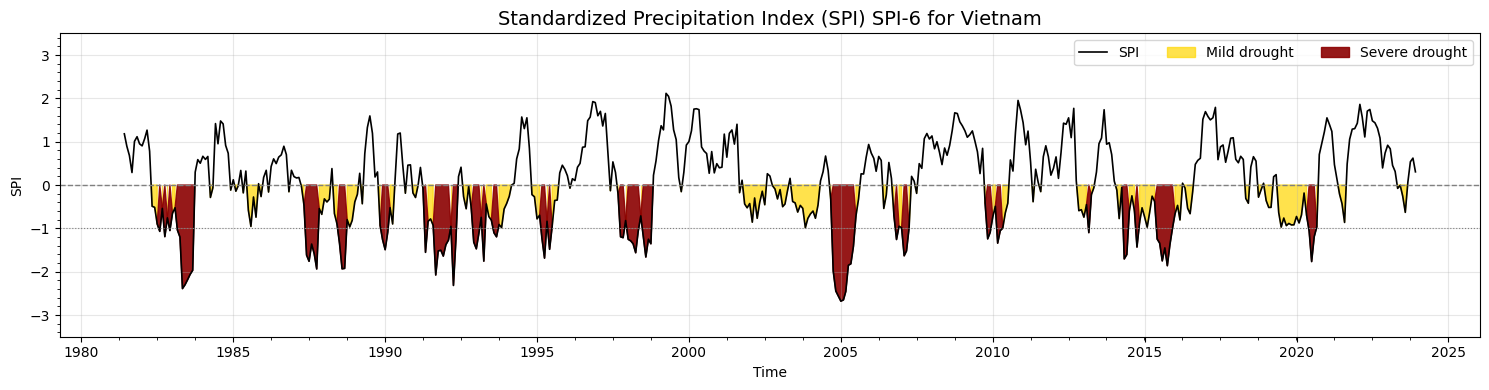

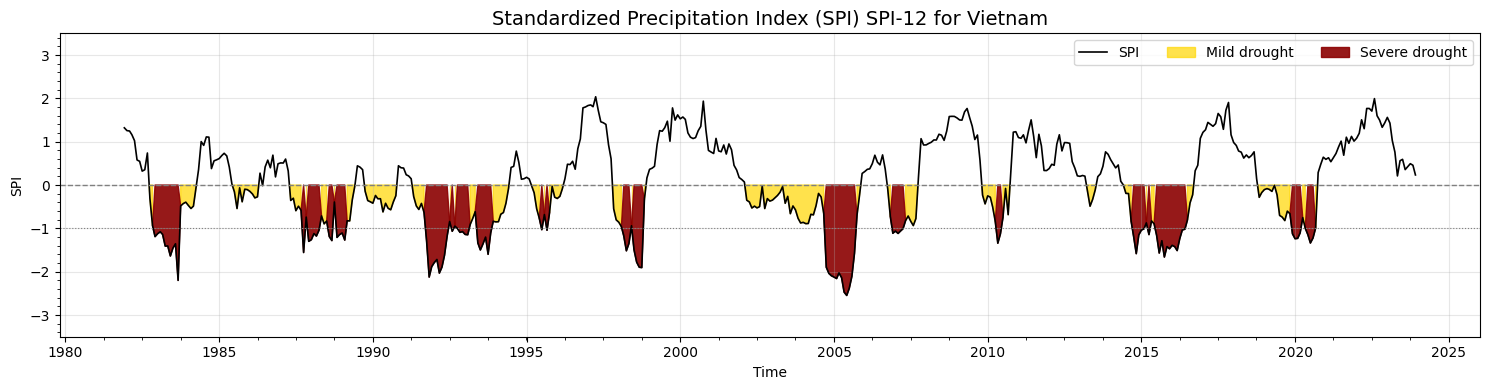

In [22]:
def plot_spi_drought_severity(spi, title):
    fig, ax = plt.subplots(figsize=(15,4))

    # Serie SPI
    ax.plot(spi.time, spi, color='black', lw=1.2, label='SPI')

    # Línea de referencia
    ax.axhline(0, color='gray', linestyle='--', lw=1)

    # Mild drought (0 a -0.99)
    ax.fill_between(
        spi.time, spi, 0,
        where=((spi < 0) & (spi > -1)),
        interpolate=True,
        color='gold',
        alpha=0.7,
        label='Mild drought'
    )

    # Severe drought (<= -1.00)
    ax.fill_between(
        spi.time, spi, 0,
        where=(spi <= -1.0),
        interpolate=True,
        color='darkred',
        alpha=0.9,
        label='Severe drought'
    )

    # Formato
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Time")
    ax.set_ylabel("SPI")
    ax.set_ylim(-3.5, 3.5)

    # Líneas horizontales de referencia
    ax.axhline(-1.0, color='gray', ls=':', lw=0.8)


    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', ncol=4, frameon=True)
    ax.minorticks_on()
    plt.tight_layout()
    plt.show()


# Graficar
plot_spi_drought_severity(spi_1m_viet, "Standardized Precipitation Index (SPI) SPI-1 for Vietnam")
plot_spi_drought_severity(spi_6m_viet, "Standardized Precipitation Index (SPI) SPI-6 for Vietnam")
plot_spi_drought_severity(spi_12m_viet, "Standardized Precipitation Index (SPI) SPI-12 for Vietnam")

#### Indonesia

In [23]:
precip_ind_1d = precip_ind.mean(dim=["latitude", "longitude"])
spi_1m_ind = xclim.indicators.atmos.standardized_precipitation_index(pr=precip_ind_1d, freq='MS', window=1)
spi_6m_ind = xclim.indicators.atmos.standardized_precipitation_index(pr=precip_ind_1d, freq='MS', window=6)
spi_12m_ind = xclim.indicators.atmos.standardized_precipitation_index(pr=precip_ind_1d, freq='MS', window=12)

/usr/local/lib/python3.12/dist-packages/xclim/core/cfchecks.py:77: UserWarning: Variable does not have a `cell_methods` attribute.
  _check_cell_methods(getattr(vardata, "cell_methods", None), data["cell_methods"])
/usr/local/lib/python3.12/dist-packages/xclim/core/cfchecks.py:79: UserWarning: Variable has a non-conforming standard_name: Got `convective precipitation rate`, expected `['precipitation_flux']`
  check_valid(vardata, "standard_name", data["standard_name"])
/usr/local/lib/python3.12/dist-packages/xclim/core/cfchecks.py:77: UserWarning: Variable does not have a `cell_methods` attribute.
  _check_cell_methods(getattr(vardata, "cell_methods", None), data["cell_methods"])
/usr/local/lib/python3.12/dist-packages/xclim/core/cfchecks.py:79: UserWarning: Variable has a non-conforming standard_name: Got `convective precipitation rate`, expected `['precipitation_flux']`
  check_valid(vardata, "standard_name", data["standard_name"])
/usr/local/lib/python3.12/dist-packages/xclim/core/c

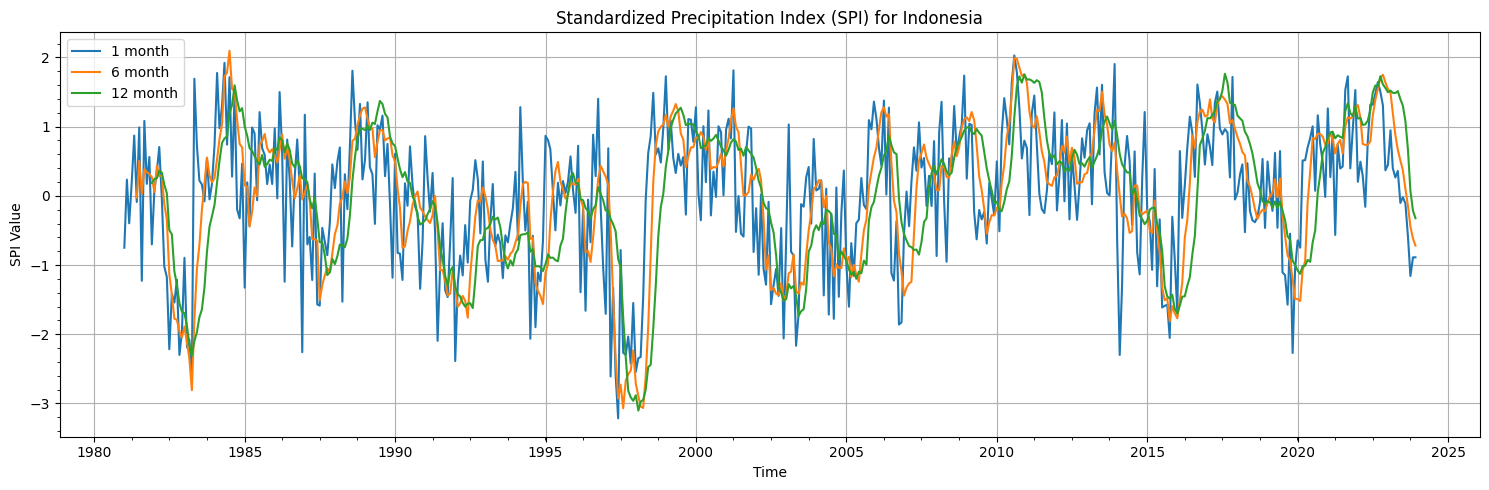

In [24]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(spi_1m_ind['time'], spi_1m_ind, label='1 month')
ax.plot(spi_6m_ind['time'], spi_6m_ind, label='6 month')
ax.plot(spi_12m_ind['time'], spi_12m_ind, label='12 month')

ax.legend()
ax.set_title('Standardized Precipitation Index (SPI) for Indonesia')
ax.set_xlabel('Time')
ax.set_ylabel('SPI Value')
ax.minorticks_on()
plt.grid(True)
plt.tight_layout()
plt.show()

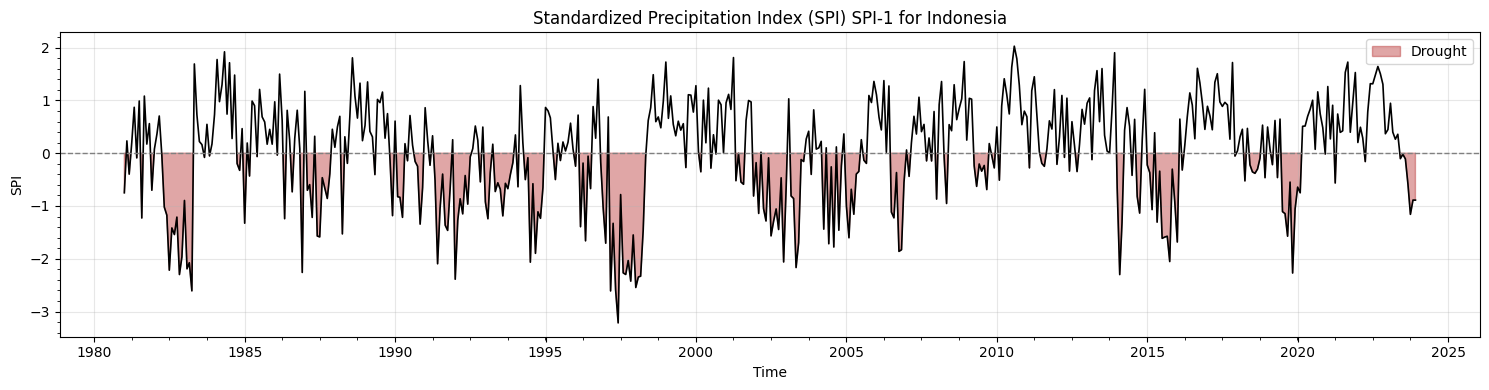

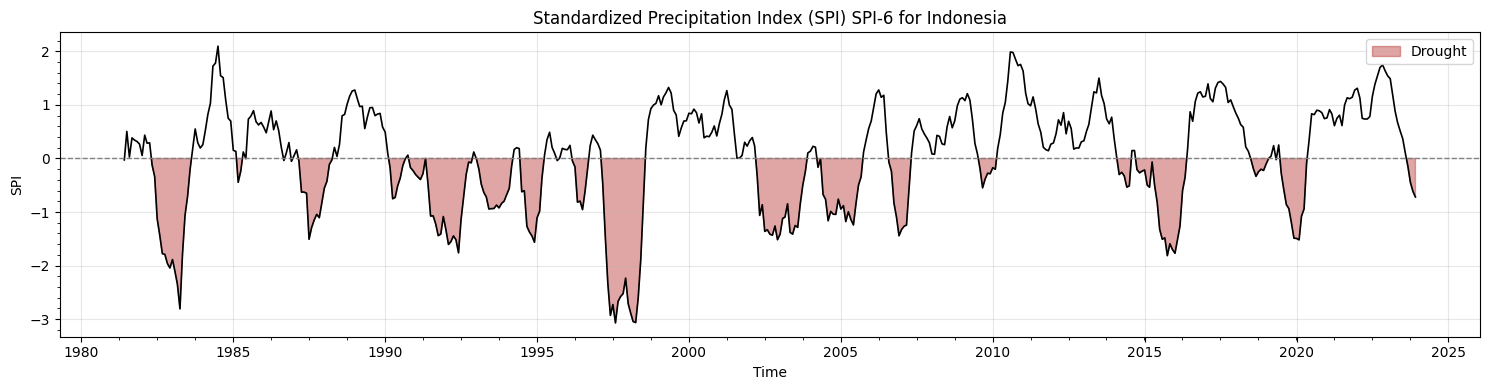

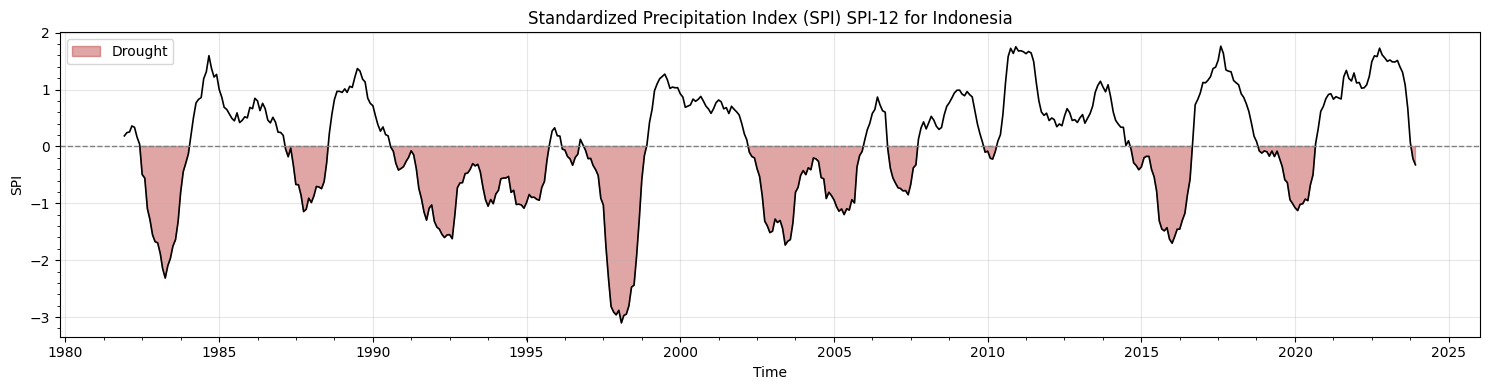

In [25]:
# Graficar cada escala
plot_spi_drought(spi_1m_ind, "Standardized Precipitation Index (SPI) SPI-1 for Indonesia")
plot_spi_drought(spi_6m_ind, "Standardized Precipitation Index (SPI) SPI-6 for Indonesia")
plot_spi_drought(spi_12m_ind, "Standardized Precipitation Index (SPI) SPI-12 for Indonesia")

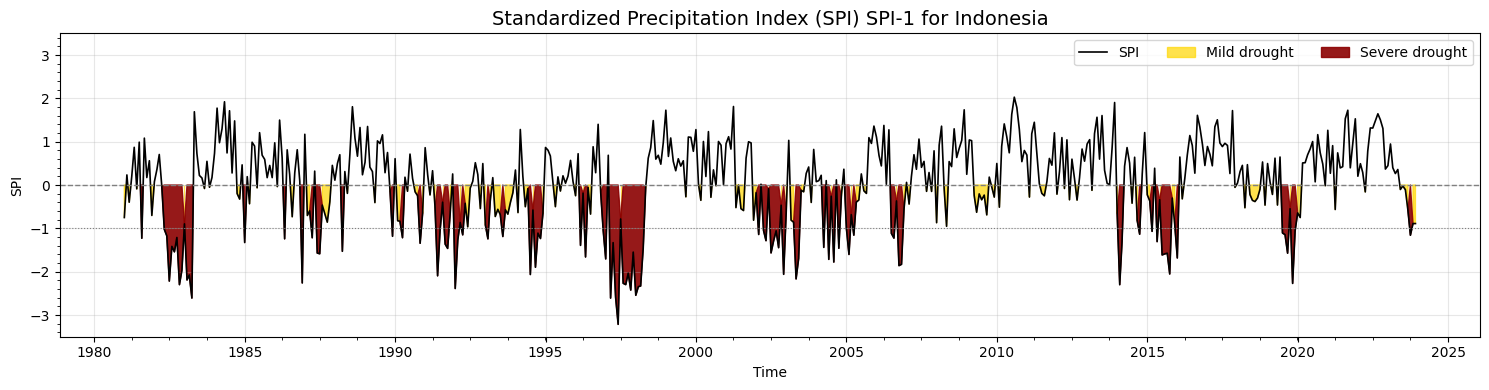

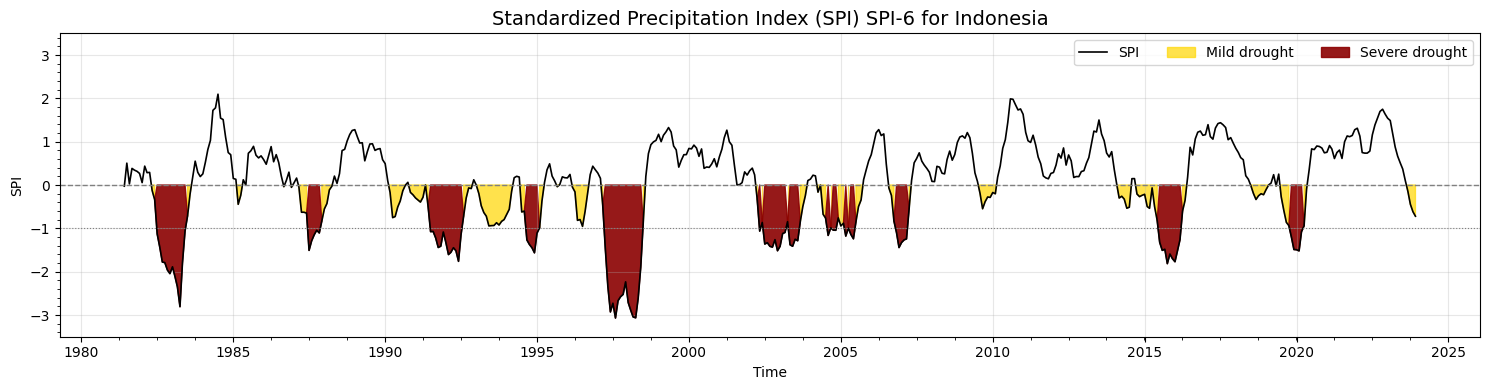

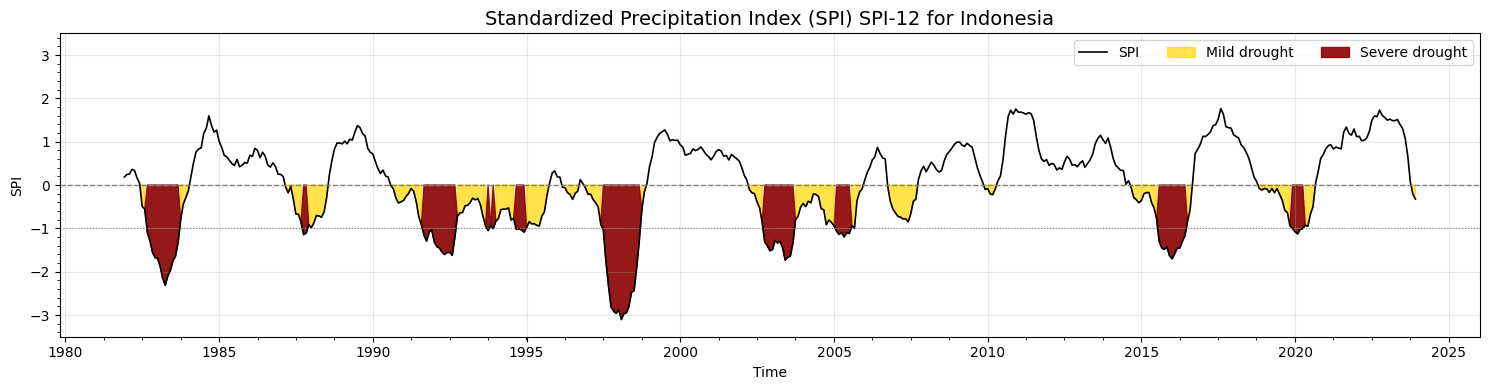

In [26]:
plot_spi_drought_severity(spi_1m_ind, "Standardized Precipitation Index (SPI) SPI-1 for Indonesia")
plot_spi_drought_severity(spi_6m_ind, "Standardized Precipitation Index (SPI) SPI-6 for Indonesia")
plot_spi_drought_severity(spi_12m_ind, "Standardized Precipitation Index (SPI) SPI-12 for Indonesia")

### Drought Severity Classification

In [27]:
# Functions for creating dataframe with drought severity classifications
def monthly_severity_per_year(x):
  '''takes x, an xarray.DataArray with variable 'spi' monthly and outputs a pandas dataframe of the number of months at each severity level per year'''
  yearly = x.groupby('time.year').map(lambda x: x.groupby_bins(x, bins=[-np.inf, -1, 0, np.inf]).count()).fillna(0)
  yearly = yearly.to_dataframe().pivot_table(index = 'year', columns = 'spi_bins')
  yearly.columns = yearly.columns.droplevel(0)
  new_column_names = ['Severe', 'Mild', 'No Drought']
  yearly.columns = new_column_names
  return yearly

def categorize_spi(spi_data_array):
  """
  Categorizes SPI values into drought severity levels.

  Takes an xarray DataArray containing 12m SPI values with a 'time' coordinate.

  Returns a pandas DataFrame with the annual 'spi' and its 'category'
  """
  spi_12m_annual = spi_data_array.resample(time='1YE').last()
  spi_12m_annual_pd = spi_12m_annual.to_pandas()
  spi_12m_annual_pd.index = spi_12m_annual_pd.index.year
  spi_12m_annual_pd.index.name = 'year'
  spi_values = spi_12m_annual_pd.rename('SPI Value')

  # Define bins and labels for drought severity
  bins = [-np.inf, -1.0, 0, np.inf]
  labels = ['Severe Drought', 'Mild Drought', 'No Drought']

  # Categorize SPI values
  spi_category = pd.cut(spi_values, bins=bins, labels=labels, right=False)

  # Create a DataFrame from the results
  result_df = pd.DataFrame({
      'spi': spi_values,
      'category': spi_category
  })

  return result_df

In [28]:
# Calculates drought severity for Vietnam
per_year_months_at_severity_level_viet = monthly_severity_per_year(spi_1m_viet)
spi_yearly_viet = categorize_spi(spi_12m_viet)
annual_spi_viet = per_year_months_at_severity_level_viet.join(spi_yearly_viet)
annual_spi_viet.to_csv(path_gd + 'annual_spi_vietnam.csv')
annual_spi_viet

,Severe,Mild,No Drought,spi,category
year,,,,,
1981,0.0,4.0,8.0,1.320154,No Drought
1982,3.0,6.0,3.0,-1.190217,Severe Drought
1983,4.0,4.0,4.0,-0.395592,Mild Drought
1984,2.0,4.0,6.0,0.581572,No Drought
1985,1.0,6.0,5.0,-0.105667,Mild Drought
1986,2.0,3.0,7.0,0.489772,No Drought
1987,4.0,5.0,3.0,-1.299901,Severe Drought
1988,4.0,6.0,2.0,-1.144015,Severe Drought
1989,5.0,1.0,6.0,-0.386355,Mild Drought


In [29]:
# Calculates drought severity for Indonesia
per_year_months_at_severity_level_indonesia = monthly_severity_per_year(spi_1m_ind)
spi_yearly_indonesia = categorize_spi(spi_12m_ind)
annual_spi_indonesia = per_year_months_at_severity_level_indonesia.join(spi_yearly_indonesia)
annual_spi_indonesia.to_csv(path_gd + 'annual_spi_indonesia.csv')
annual_spi_indonesia

,Severe,Mild,No Drought,spi,category
year,,,,,
1981,1.0,4.0,7.0,0.185277,No Drought
1982,8.0,1.0,3.0,-1.673698,Severe Drought
1983,3.0,3.0,6.0,-0.294650,Mild Drought
1984,0.0,2.0,10.0,1.266622,No Drought
1985,1.0,2.0,9.0,0.502711,No Drought
1986,2.0,2.0,8.0,0.251172,No Drought
1987,3.0,6.0,3.0,-0.910255,Mild Drought
1988,1.0,1.0,10.0,0.968776,No Drought
1989,1.0,2.0,9.0,0.757470,No Drought


## Cereal Production


1.   Start with raw values
2.   Detrend by linear fit (or piecewise-linear or nonparametric if needed)
3.   Calculate anomaly
4.   Normalize anomaly



In [30]:
#Selectiong countries and columns of interest
columns_of_interest = ['Country Name', 'Country Code'] + years
target_countries = ['Indonesia', 'Viet Nam']
cereal_land_countries = cereal_df[cereal_df['Country Name'].isin(target_countries)]
existing_columns = [col for col in columns_of_interest if col in cereal_land_countries.columns]
cereal_land_filtered = cereal_land_countries[existing_columns]
cereal_land_long_VI = cereal_land_filtered.melt(
    id_vars=['Country Name', 'Country Code'],
    var_name='Year',
    value_name='Production'
)
cereal_land_long_VI

,Country Name,Country Code,Year,Production
0,Indonesia,IDN,1981,37283478.00
1,Viet Nam,VNM,1981,12844800.00
2,Indonesia,IDN,1982,36818521.00
3,Viet Nam,VNM,1982,14828300.00
4,Indonesia,IDN,1983,40389883.00
...,...,...,...,...
81,Viet Nam,VNM,2021,48301162.59
82,Indonesia,IDN,2022,77105730.08
83,Viet Nam,VNM,2022,47085607.10
84,Indonesia,IDN,2023,73966646.00


### Detrending
Detrend cereal production with linear fit

Text(0, 0.5, 'Detrended production')

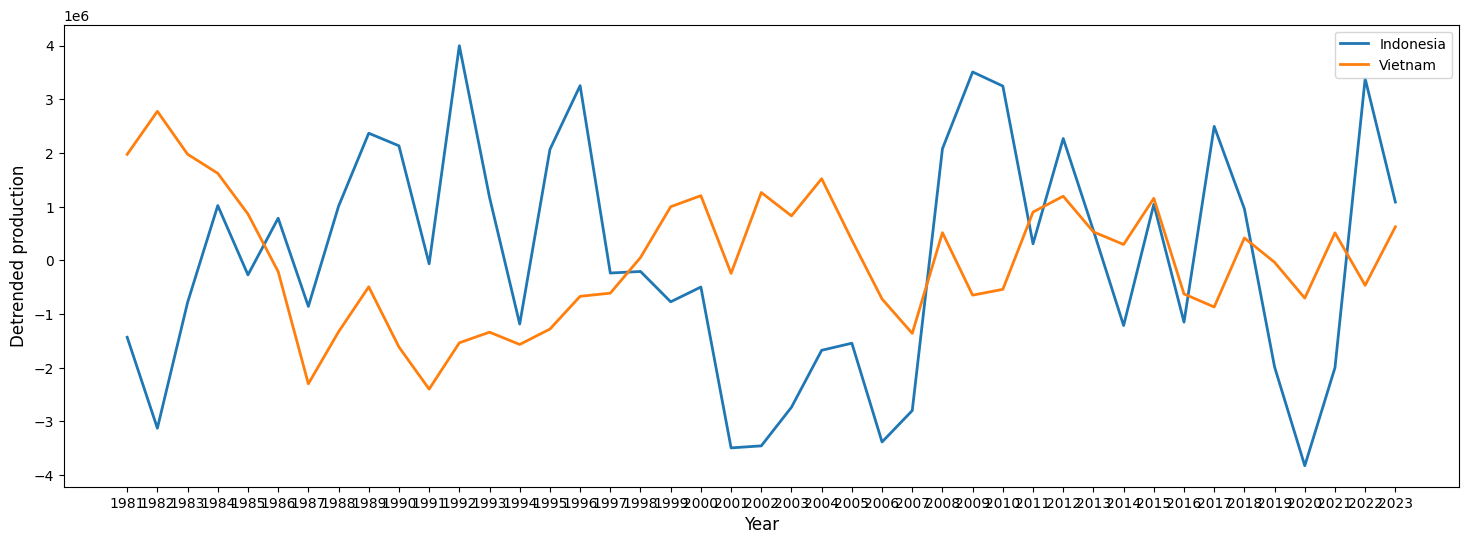

In [31]:
#detrend production data by country
#linear detrend with breakpoint at 2015 (index=34)
cereal_land_long_VI["detrended"] = cereal_land_long_VI.groupby(cereal_land_long_VI['Country Name'])["Production"].transform(
    lambda x: scipy.signal.detrend(x, type='linear', bp=34)
)

fig, ax = plt.subplots(figsize=(18, 6))
for countries in ['Indonesia', 'Viet Nam']:
    country_data = cereal_land_long_VI[cereal_land_long_VI['Country Name'] == countries]
    ax.plot(country_data['Year'] , country_data['detrended'], linewidth=2, label=countries)

plt.legend(['Indonesia', 'Vietnam'])
plt.xlabel('Year', fontsize=12)
plt.ylabel('Detrended production', fontsize=12)

### Normalized Anomalies

In [32]:
# Helper function
def add_anomaly(df, colname):
  '''
  takes a pandas dataframe with a Country Name column and finds the anomaly and a normalized anomoly of the column given by "colname"
  '''
  df_out = df.copy()

  # Calculate mean per country
  df_out[colname + '_Mean'] = df_out.groupby('Country Name')[colname].transform('mean')
  df_out['Anomaly'] = df_out[colname] - df_out[colname + '_Mean']

  # Calculating standard deviation for each country
  df_out[colname + '_Std'] = df_out.groupby('Country Name')[colname].transform('std')

  # Normalizing anomaly (Z-score)
  df_out['Anomaly_Normalized'] = df_out['Anomaly'] / df_out[colname + '_Std']

  return df_out


In [33]:
cereal_land_long_VI = add_anomaly(cereal_land_long_VI, "detrended")
cereal_land_long_VI

,Country Name,Country Code,Year,Production,detrended,detrended_Mean,Anomaly,detrended_Std,Anomaly_Normalized
0,Indonesia,IDN,1981,37283478.00,-1.433609e+06,4.851541e-09,-1.433609e+06,2.158616e+06,-0.664133
1,Viet Nam,VNM,1981,12844800.00,1.973415e+06,1.433804e-08,1.973415e+06,1.203843e+06,1.639262
2,Indonesia,IDN,1982,36818521.00,-3.127823e+06,4.851541e-09,-3.127823e+06,2.158616e+06,-1.448995
3,Viet Nam,VNM,1982,14828300.00,2.774720e+06,1.433804e-08,2.774720e+06,1.203843e+06,2.304885
4,Indonesia,IDN,1983,40389883.00,-7.857188e+05,4.851541e-09,-7.857188e+05,2.158616e+06,-0.363992
...,...,...,...,...,...,...,...,...,...
81,Viet Nam,VNM,2021,48301162.59,5.106349e+05,1.433804e-08,5.106349e+05,1.203843e+06,0.424171
82,Indonesia,IDN,2022,77105730.08,3.383882e+06,4.851541e-09,3.383882e+06,2.158616e+06,1.567616
83,Viet Nam,VNM,2022,47085607.10,-4.657799e+05,1.433804e-08,-4.657799e+05,1.203843e+06,-0.386911
84,Indonesia,IDN,2023,73966646.00,1.084660e+06,4.851541e-09,1.084660e+06,2.158616e+06,0.502479


In [34]:
# # Save dataset as CSV file
# path_gd = "/content/drive/MyDrive/Group Project Folder/Data/"
cereal_land_long_VI.to_csv(path_gd + 'detrended_normalized_anomaly_cerial_data.csv', index=False)

# Analysis

In [35]:
cereal_land_long_VI

,Country Name,Country Code,Year,Production,detrended,detrended_Mean,Anomaly,detrended_Std,Anomaly_Normalized
0,Indonesia,IDN,1981,37283478.00,-1.433609e+06,4.851541e-09,-1.433609e+06,2.158616e+06,-0.664133
1,Viet Nam,VNM,1981,12844800.00,1.973415e+06,1.433804e-08,1.973415e+06,1.203843e+06,1.639262
2,Indonesia,IDN,1982,36818521.00,-3.127823e+06,4.851541e-09,-3.127823e+06,2.158616e+06,-1.448995
3,Viet Nam,VNM,1982,14828300.00,2.774720e+06,1.433804e-08,2.774720e+06,1.203843e+06,2.304885
4,Indonesia,IDN,1983,40389883.00,-7.857188e+05,4.851541e-09,-7.857188e+05,2.158616e+06,-0.363992
...,...,...,...,...,...,...,...,...,...
81,Viet Nam,VNM,2021,48301162.59,5.106349e+05,1.433804e-08,5.106349e+05,1.203843e+06,0.424171
82,Indonesia,IDN,2022,77105730.08,3.383882e+06,4.851541e-09,3.383882e+06,2.158616e+06,1.567616
83,Viet Nam,VNM,2022,47085607.10,-4.657799e+05,1.433804e-08,-4.657799e+05,1.203843e+06,-0.386911
84,Indonesia,IDN,2023,73966646.00,1.084660e+06,4.851541e-09,1.084660e+06,2.158616e+06,0.502479


## SPI & Cereal Correlation


In [36]:
annual_spi_viet.index

Index([1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992,
       1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016,
       2017, 2018, 2019, 2020, 2021, 2022, 2023],
      dtype='int64', name='year')

In [37]:
cereal_land_long_VI.Year = cereal_land_long_VI.Year.astype(int)

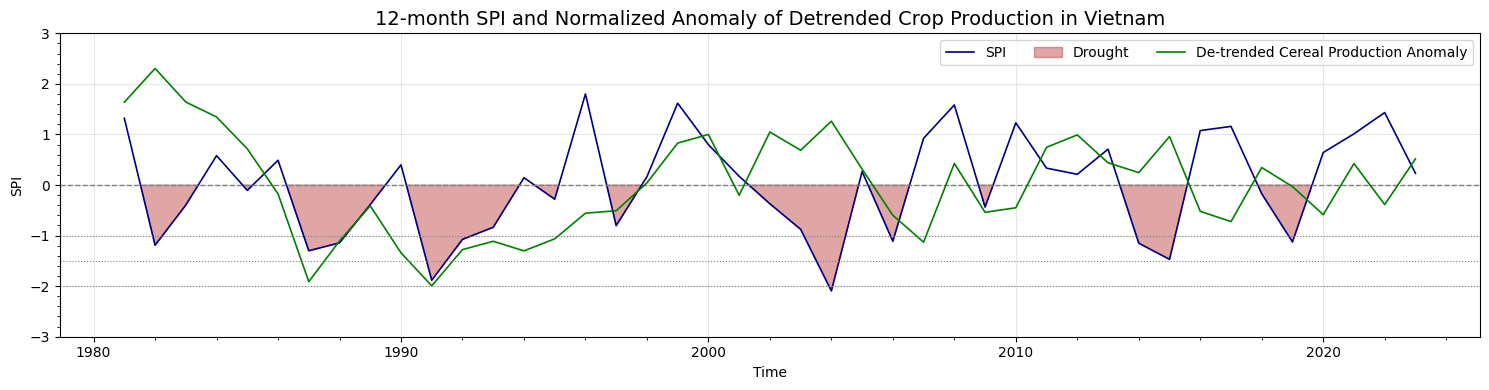

In [38]:
fig, ax = plt.subplots(figsize=(15,4))

# Serie SPI
ax.plot(annual_spi_viet.index, annual_spi_viet.spi, color='navy', lw=1.2, label='SPI')

# Línea de referencia
ax.axhline(0, color='gray', linestyle='--', lw=1)

# Sombrear sequía (SPI < 0)
ax.fill_between(
    annual_spi_viet.index,
    annual_spi_viet.spi,
    0,
    where=(annual_spi_viet.spi < 0),
    interpolate=True,
    color='firebrick',
    alpha=0.4,
    label='Drought'
)

data = cereal_land_long_VI[cereal_land_long_VI['Country Name'] == 'Viet Nam']
# Use data_years_datetime for plotting the cereal anomaly
ax.plot(data.Year, data['Anomaly_Normalized'], color = 'green', linewidth=1.2, label='De-trended Cereal Production Anomaly')

# Formato
ax.set_title('12-month SPI and Normalized Anomaly of Detrended Crop Production in Vietnam', fontsize=14)
ax.set_xlabel("Time")
ax.set_ylabel("SPI")
ax.set_ylim(-3, 3)

# Líneas horizontales de referencia
ax.axhline(-1.0, color='gray', ls=':', lw=0.8)
ax.axhline(-1.5, color='gray', ls=':', lw=0.8)
ax.axhline(-2.0, color='gray', ls=':', lw=0.8)

ax.grid(alpha=0.3)
ax.minorticks_on()
ax.legend(loc='upper right', ncol=4, frameon=True)

plt.tight_layout()
plt.show()

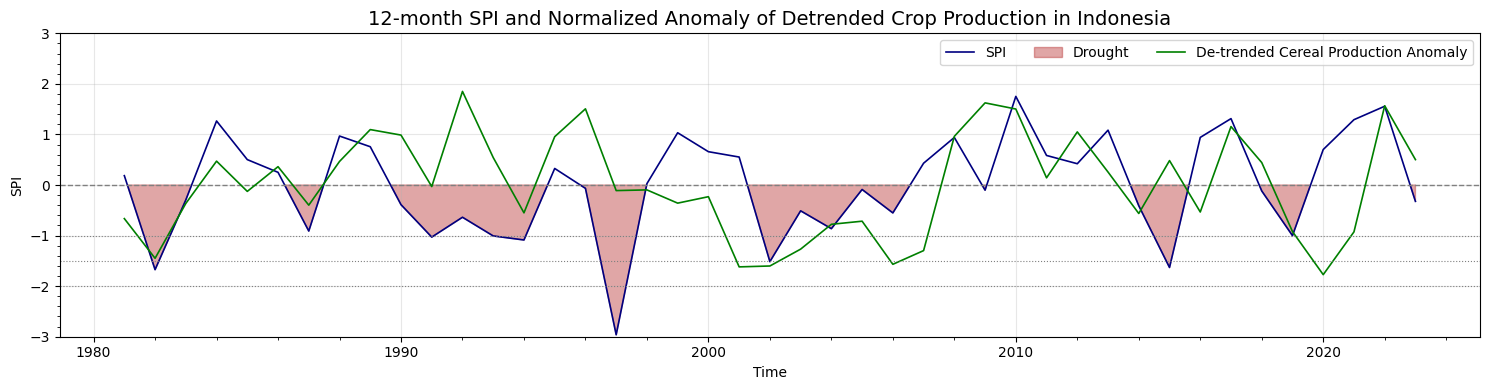

In [39]:
fig, ax = plt.subplots(figsize=(15,4))

# Serie SPI
ax.plot(annual_spi_indonesia.index, annual_spi_indonesia.spi, color='navy', lw=1.2, label='SPI')

# Línea de referencia
ax.axhline(0, color='gray', linestyle='--', lw=1)

# Sombrear sequía (SPI < 0)
ax.fill_between(
    annual_spi_indonesia.index,
    annual_spi_indonesia.spi,
    0,
    where=(annual_spi_indonesia.spi < 0),
    interpolate=True,
    color='firebrick',
    alpha=0.4,
    label='Drought'
)

data = cereal_land_long_VI[cereal_land_long_VI['Country Name'] == 'Indonesia']
# Use data_years_datetime for plotting the cereal anomaly
ax.plot(data.Year, data['Anomaly_Normalized'], color = 'green', linewidth=1.2, label='De-trended Cereal Production Anomaly')

# Formato
ax.set_title('12-month SPI and Normalized Anomaly of Detrended Crop Production in Indonesia', fontsize=14)
ax.set_xlabel("Time")
ax.set_ylabel("SPI")
ax.set_ylim(-3, 3)

# Líneas horizontales de referencia
ax.axhline(-1.0, color='gray', ls=':', lw=0.8)
ax.axhline(-1.5, color='gray', ls=':', lw=0.8)
ax.axhline(-2.0, color='gray', ls=':', lw=0.8)

ax.grid(alpha=0.3)
ax.minorticks_on()
ax.legend(loc='upper right', ncol=4, frameon=True)

plt.tight_layout()
plt.show()

In [40]:
def prep_corr(df, spi_df, country):
  '''takes a pandas dataframe with a "Country Name" column and a country name found within the "Country Name" column and provides a joined truncated dataframe of the relevant columns'''
  new_df = df.loc[df['Country Name'] == country].set_index('Year')
  new_df.index.name = 'year'
  new_df.index = new_df.index.astype('int')
  new_df = spi_df.join(new_df)
  new_df = new_df.loc[:2023, :]
  return new_df

In [41]:
crops_and_spi_ind = prep_corr(cereal_land_long_VI, annual_spi_indonesia, 'Indonesia')

In [42]:
crops_and_spi_viet = prep_corr(cereal_land_long_VI, annual_spi_viet, 'Viet Nam')

In [43]:
crops_and_spi_ind.groupby('category')['Anomaly_Normalized'].agg(['mean', 'median'])

/tmp/ipykernel_1697/738625448.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  crops_and_spi_ind.groupby('category')['Anomaly_Normalized'].agg(['mean', 'median'])


,mean,median
category,,
Severe Drought,-0.454366,-0.329923
Mild Drought,0.097363,-0.363992
No Drought,0.107691,0.199426


In [44]:
# Independence Assumption may be Violated
# Define the model
model = ols('Anomaly ~ C(category)', data=crops_and_spi_ind).fit()

# Perform ANOVA
anova_table = sm.stats.anova_lm(model, typ=1)
print(anova_table)

               df        sum_sq       mean_sq         F    PR(>F)
C(category)   2.0  9.458864e+12  4.729432e+12  1.015742  0.371283
Residual     40.0  1.862454e+14  4.656134e+12       NaN       NaN


In [45]:
correlation_coefficient, p_value = pearsonr(crops_and_spi_ind.spi.values, crops_and_spi_ind.Anomaly_Normalized.values)

In [46]:
crops_and_spi_ind[['spi', 'Anomaly_Normalized']].corr()

,spi,Anomaly_Normalized
spi,1.000000,0.279395
Anomaly_Normalized,0.279395,1.000000


In [47]:
correlation_coefficient, p_value = pearsonr(crops_and_spi_ind.spi.values, crops_and_spi_ind.Anomaly_Normalized.values)
print (correlation_coefficient, p_value)

0.27939547227819195 0.06960760966865313


In [48]:
correlation_coefficient, p_value = pearsonr(crops_and_spi_viet.spi.values, crops_and_spi_viet.Anomaly_Normalized.values)
print (correlation_coefficient, p_value)

0.09778070640202238 0.5327624886849652


## Drought Severity Analysis
TODO: Subset each SPI series by drought severity category to then assess relationship between drought severity and crop production. Can create scatter plots and time series. Do for each domain.

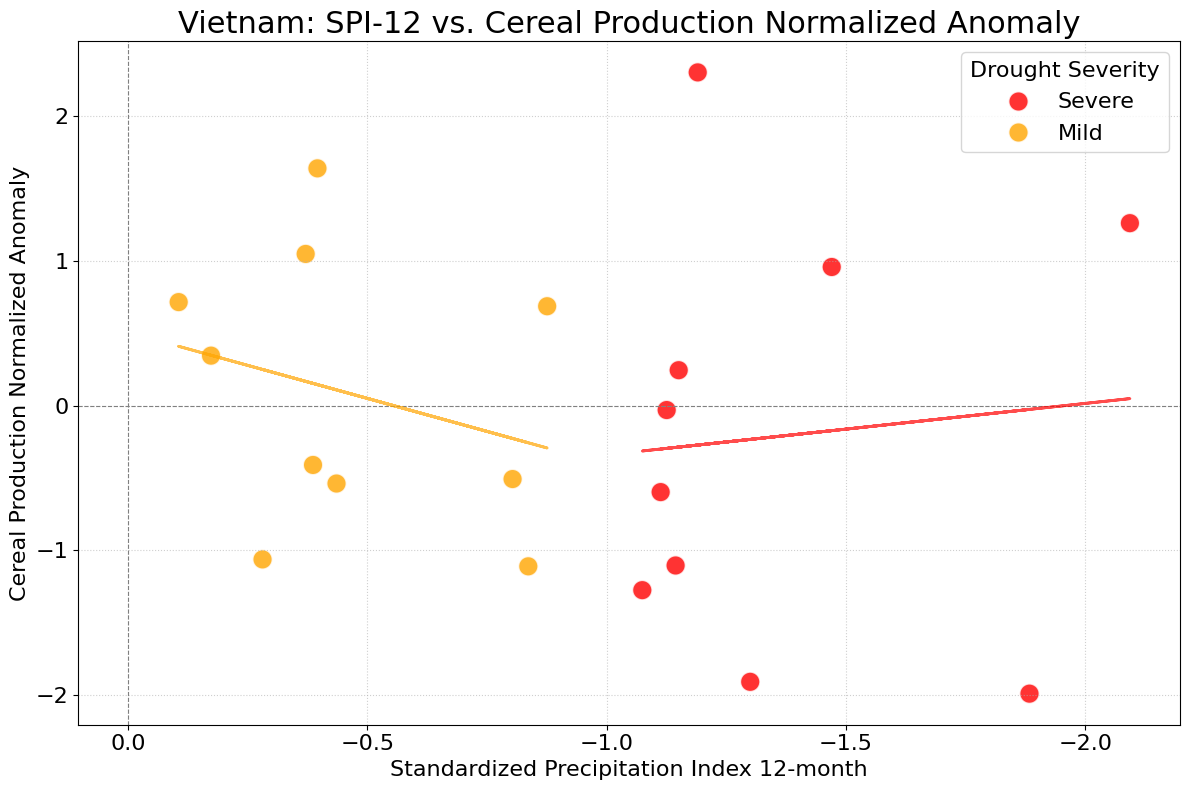

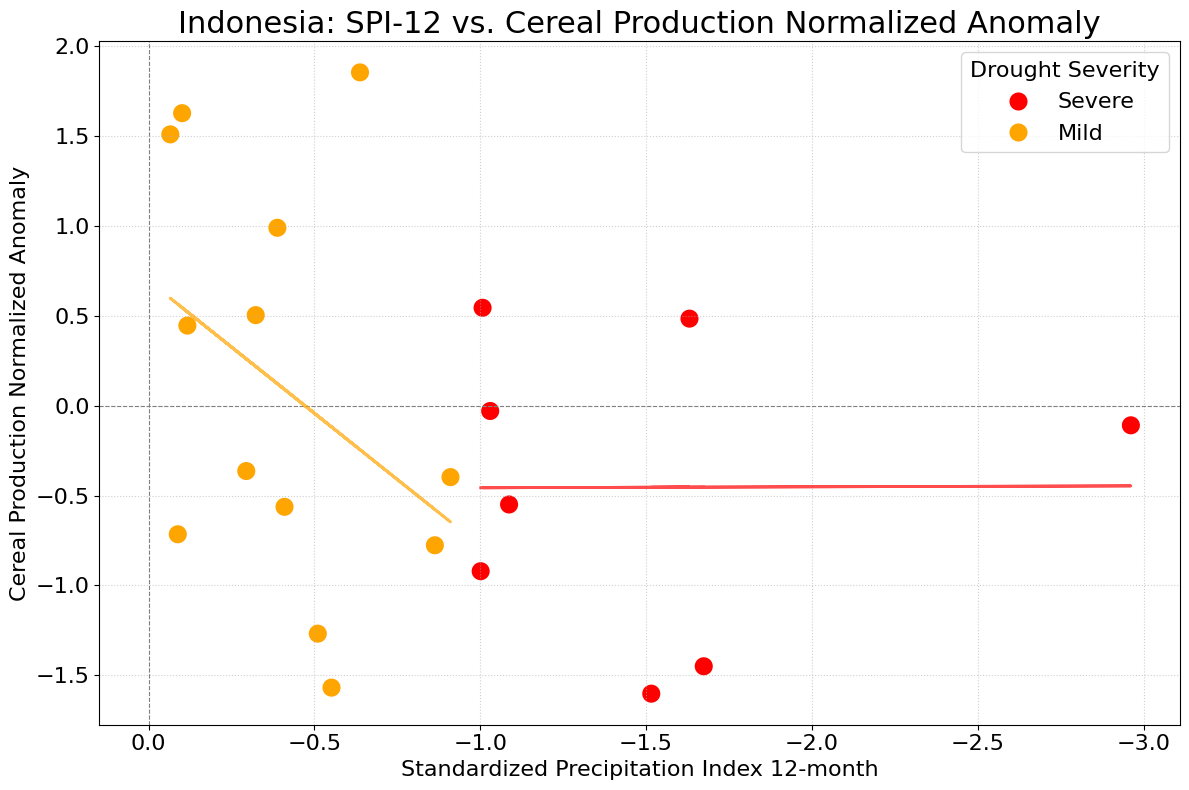

,Country,Severity,Correlation (r),p-value,Slope
0,Vietnam,Severe,-0.089,0.807,-0.356
1,Vietnam,Mild,0.270,0.451,0.913
2,Indonesia,Severe,-0.004,0.992,-0.005
3,Indonesia,Mild,0.367,0.217,1.472


In [49]:
import scipy.stats as stats # Ensure scipy.stats is imported for statistical functions

# Ensure 'Year' column in cereal_land_long_VI is integer for merging
cereal_land_long_VI['Year'] = cereal_land_long_VI['Year'].astype(int)

# --- Vietnam --- #
# Filter cereal data for Vietnam
cereal_viet = cereal_land_long_VI[cereal_land_long_VI['Country Name'] == 'Viet Nam']

# Merge annual SPI data for Vietnam with cereal production data
merged_viet = pd.merge(cereal_viet, annual_spi_viet, left_on='Year', right_on='year', how='inner')

# --- Indonesia --- #
# Filter cereal data for Indonesia
cereal_ind = cereal_land_long_VI[cereal_land_long_VI['Country Name'] == 'Indonesia']

# Merge annual SPI data for Indonesia with cereal production data
merged_ind = pd.merge(cereal_ind, annual_spi_indonesia, left_on='Year', right_on='year', how='inner')

# Define custom color palette for drought severity (excluding 'No Drought' as per request)
drought_colors_filtered = {
    'Severe': 'red',
    'Mild': 'orange'
}

# Initialize list to hold stats for the final table
stats_summary = []

# Filter out 'No Drought' for Vietnam and rename the categories
merged_viet_filtered = merged_viet[merged_viet['category'] != 'No Drought'].copy()
merged_viet_filtered['category'] = merged_viet_filtered['category'].astype(str).replace({'Severe Drought': 'Severe', 'Mild Drought': 'Mild'})

# Plot for Vietnam
plt.figure(figsize=(12, 8))
ax = sns.scatterplot(
    data=merged_viet_filtered,
    x='spi',
    y='Anomaly_Normalized',
    hue='category',
    palette=drought_colors_filtered,
    s=200, # Increased by 100%
    alpha=0.8
)
plt.title('Vietnam: SPI-12 vs. Cereal Production Normalized Anomaly', fontsize=22) # Increased by 50%
plt.xlabel('Standardized Precipitation Index 12-month', fontsize=16) # Increased by 30%
plt.ylabel('Cereal Production Normalized Anomaly', fontsize=16) # Increased by 30%
plt.xticks(fontsize=16) # Increased by 30%
plt.yticks(fontsize=16) # Increased by 30%
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='Drought Severity', loc='upper right', fontsize=16, title_fontsize=16)
plt.gca().invert_xaxis()

# Calculate statistics for Vietnam
for category in ['Severe', 'Mild']:
    subset = merged_viet_filtered[merged_viet_filtered['category'] == category]
    if len(subset) > 1:
        x_data = subset['spi']
        y_data = subset['Anomaly_Normalized']
        r, p_corr = stats.pearsonr(x_data, y_data)
        slope, intercept, r_value, p_reg, std_err = stats.linregress(x_data, y_data)
        ax.plot(x_data, intercept + slope * x_data, color=drought_colors_filtered[category], linestyle='-', linewidth=2, alpha=0.7)
        stats_summary.append({'Country': 'Vietnam', 'Severity': category, 'Correlation (r)': round(r, 3), 'p-value': round(p_corr, 3), 'Slope': round(slope, 3)})
    else:
        stats_summary.append({'Country': 'Vietnam', 'Severity': category, 'Correlation (r)': None, 'p-value': None, 'Slope': None})

plt.tight_layout()
plt.show()

# Filter out 'No Drought' for Indonesia and rename the categories
merged_ind_filtered = merged_ind[merged_ind['category'] != 'No Drought'].copy()
merged_ind_filtered['category'] = merged_ind_filtered['category'].astype(str).replace({'Severe Drought': 'Severe', 'Mild Drought': 'Mild'})

# Plot for Indonesia
plt.figure(figsize=(12, 8))
ax = sns.scatterplot(
    data=merged_ind_filtered,
    x='spi',
    y='Anomaly_Normalized',
    hue='category',
    palette=drought_colors_filtered,
    s=200, # Increased by 100%
    alpha=1
)
plt.title('Indonesia: SPI-12 vs. Cereal Production Normalized Anomaly', fontsize=22) # Increased by 50%
plt.xlabel('Standardized Precipitation Index 12-month', fontsize=16) # Increased by 30%
plt.ylabel('Cereal Production Normalized Anomaly', fontsize=16) # Increased by 30%
plt.xticks(fontsize=16) # Increased by 30%
plt.yticks(fontsize=16) # Increased by 30%
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='Drought Severity', loc='upper right', fontsize=16, title_fontsize=16)
plt.gca().invert_xaxis()

# Calculate statistics for Indonesia
for category in ['Severe', 'Mild']:
    subset = merged_ind_filtered[merged_ind_filtered['category'] == category]
    if len(subset) > 1:
        x_data = subset['spi']
        y_data = subset['Anomaly_Normalized']
        r, p_corr = stats.pearsonr(x_data, y_data)
        slope, intercept, r_value, p_reg, std_err = stats.linregress(x_data, y_data)
        ax.plot(x_data, intercept + slope * x_data, color=drought_colors_filtered[category], linestyle='-', linewidth=2, alpha=0.7)
        stats_summary.append({'Country': 'Indonesia', 'Severity': category, 'Correlation (r)': round(r, 3), 'p-value': round(p_corr, 3), 'Slope': round(slope, 3)})
    else:
        stats_summary.append({'Country': 'Indonesia', 'Severity': category, 'Correlation (r)': None, 'p-value': None, 'Slope': None})

plt.tight_layout()
plt.show()

# Display the final statistics table
stats_df = pd.DataFrame(stats_summary)
display(stats_df)

In [50]:
import scipy.stats as stats
import pandas as pd

# Drop any potential NaN values to ensure pearsonr works correctly
viet_clean = merged_viet.dropna(subset=['spi', 'Anomaly_Normalized'])
ind_clean = merged_ind.dropna(subset=['spi', 'Anomaly_Normalized'])

# Overall (All Data)
r_v_all, p_v_all = stats.pearsonr(viet_clean['spi'], viet_clean['Anomaly_Normalized'])
slope_v_all, _, _, _, _ = stats.linregress(viet_clean['spi'], viet_clean['Anomaly_Normalized'])

r_i_all, p_i_all = stats.pearsonr(ind_clean['spi'], ind_clean['Anomaly_Normalized'])
slope_i_all, _, _, _, _ = stats.linregress(ind_clean['spi'], ind_clean['Anomaly_Normalized'])

# Any Drought (Filter out 'No Drought')
viet_drought = viet_clean[viet_clean['category'] != 'No Drought']
ind_drought = ind_clean[ind_clean['category'] != 'No Drought']

r_v_d, p_v_d = stats.pearsonr(viet_drought['spi'], viet_drought['Anomaly_Normalized'])
slope_v_d, _, _, _, _ = stats.linregress(viet_drought['spi'], viet_drought['Anomaly_Normalized'])

r_i_d, p_i_d = stats.pearsonr(ind_drought['spi'], ind_drought['Anomaly_Normalized'])
slope_i_d, _, _, _, _ = stats.linregress(ind_drought['spi'], ind_drought['Anomaly_Normalized'])

# Create a new DataFrame for the new statistics
new_stats = pd.DataFrame([
    {'Country': 'Vietnam', 'Severity': 'All Data', 'Correlation (r)': round(r_v_all, 3), 'p-value': round(p_v_all, 3), 'Slope': round(slope_v_all, 3)},
    {'Country': 'Indonesia', 'Severity': 'All Data', 'Correlation (r)': round(r_i_all, 3), 'p-value': round(p_i_all, 3), 'Slope': round(slope_i_all, 3)},
    {'Country': 'Vietnam', 'Severity': 'Any Drought', 'Correlation (r)': round(r_v_d, 3), 'p-value': round(p_v_d, 3), 'Slope': round(slope_v_d, 3)},
    {'Country': 'Indonesia', 'Severity': 'Any Drought', 'Correlation (r)': round(r_i_d, 3), 'p-value': round(p_i_d, 3), 'Slope': round(slope_i_d, 3)}
])

# Clean up stats_df to prevent duplicates if cell is run multiple times
stats_df = stats_df[~stats_df['Severity'].isin(['All Data', 'Any Drought'])]

# Append to the existing stats_df
stats_df = pd.concat([stats_df, new_stats], ignore_index=True)

# Display the updated DataFrame
display(stats_df)


,Country,Severity,Correlation (r),p-value,Slope
0,Vietnam,Severe,-0.089,0.807,-0.356
1,Vietnam,Mild,0.270,0.451,0.913
2,Indonesia,Severe,-0.004,0.992,-0.005
3,Indonesia,Mild,0.367,0.217,1.472
4,Vietnam,All Data,0.098,0.533,0.097
5,Indonesia,All Data,0.279,0.070,0.278
6,Vietnam,Any Drought,0.124,0.604,0.265
7,Indonesia,Any Drought,0.299,0.188,0.443


### Dual-Axis Time Series: Crop Production vs Raw Precipitation

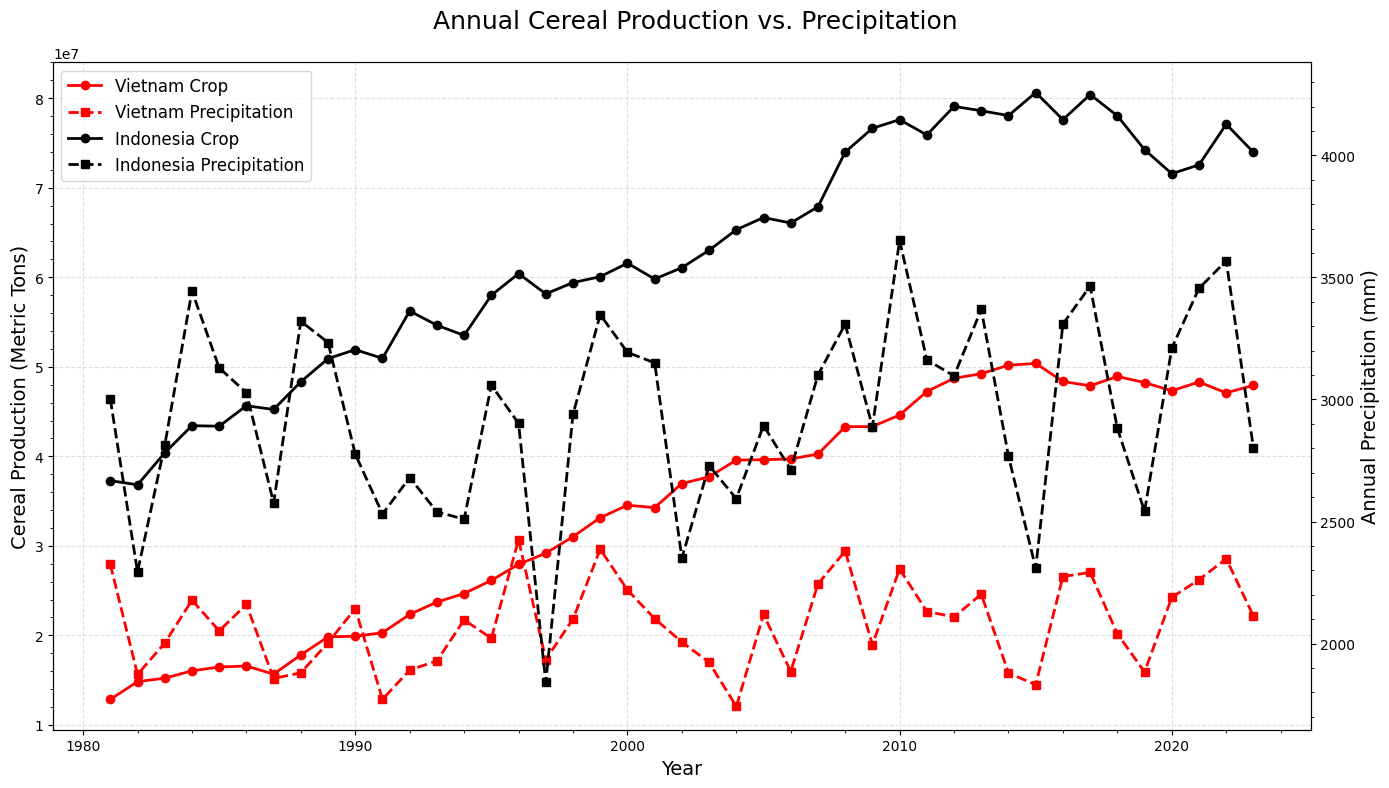

In [51]:
# Calculate annual total precipitation for both domains
annual_precip_v = precip_viet_1d.resample(time='1YE').sum(dim='time').to_dataframe(name='annual_precip')
annual_precip_v.index = annual_precip_v.index.year

annual_precip_i = precip_ind_1d.resample(time='1YE').sum(dim='time').to_dataframe(name='annual_precip')
annual_precip_i.index = annual_precip_i.index.year

# Merge with existing DataFrames containing cereal production
merged_viet_dual = merged_viet.merge(annual_precip_v, left_on='Year', right_index=True, how='inner')
merged_ind_dual = merged_ind.merge(annual_precip_i, left_on='Year', right_index=True, how='inner')

# Create a single dual-axis plot for both countries
fig, ax1 = plt.subplots(figsize=(14, 8))

color_v = 'red'
color_i = 'black'

# Axis 1: Crop Production (Left)
ax1.set_xlabel('Year', fontsize=14)
ax1.set_ylabel('Cereal Production (Metric Tons)', fontsize=14)
line1 = ax1.plot(merged_viet_dual['Year'], merged_viet_dual['Production'], color=color_v, marker='o', linewidth=2, linestyle='-', label='Vietnam Crop')
line2 = ax1.plot(merged_ind_dual['Year'], merged_ind_dual['Production'], color=color_i, marker='o', linewidth=2, linestyle='-', label='Indonesia Crop')
ax1.tick_params(axis='y')
ax1.minorticks_on()
# Axis 2: Precipitation (Right)
ax2 = ax1.twinx()
ax2.set_ylabel('Annual Precipitation (mm)', fontsize=14)
line3 = ax2.plot(merged_viet_dual['Year'], merged_viet_dual['annual_precip'], color=color_v, marker='s', linewidth=2, linestyle='--', label='Vietnam Precipitation')
line4 = ax2.plot(merged_ind_dual['Year'], merged_ind_dual['annual_precip'], color=color_i, marker='s', linewidth=2, linestyle='--', label='Indonesia Precipitation')
ax2.tick_params(axis='y')
ax2.minorticks_on()
# Title and Legend
fig.suptitle('Annual Cereal Production vs. Precipitation', fontsize=18)
fig.tight_layout()

# Combine legends from both axes and move to top left
lines = line1 + line3 + line2 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', ncol=1, fontsize=12)

# Adding grid based on left axis
ax1.grid(alpha=0.4, linestyle='--')

# Increase upper y-limit for the primary axis to make room for the legend, ensuring it doesn't overlap lines
ax2.set_ylim(top=merged_ind_dual['annual_precip'].max() * 1.2)

plt.show()


## Shared Variability of Precipitation and Cereal Production
TODO: Using best SPI with strongest correlation w/ cereal production, apply PCA to joined datasets to find leading modes of variability. Do for each domain.

=== Vietnam PCA ===
Mode 1 Explained Variance: 54.89%
Mode 2 Explained Variance: 45.11%
(Note: Only 2 modes exist because only 2 input features were provided)



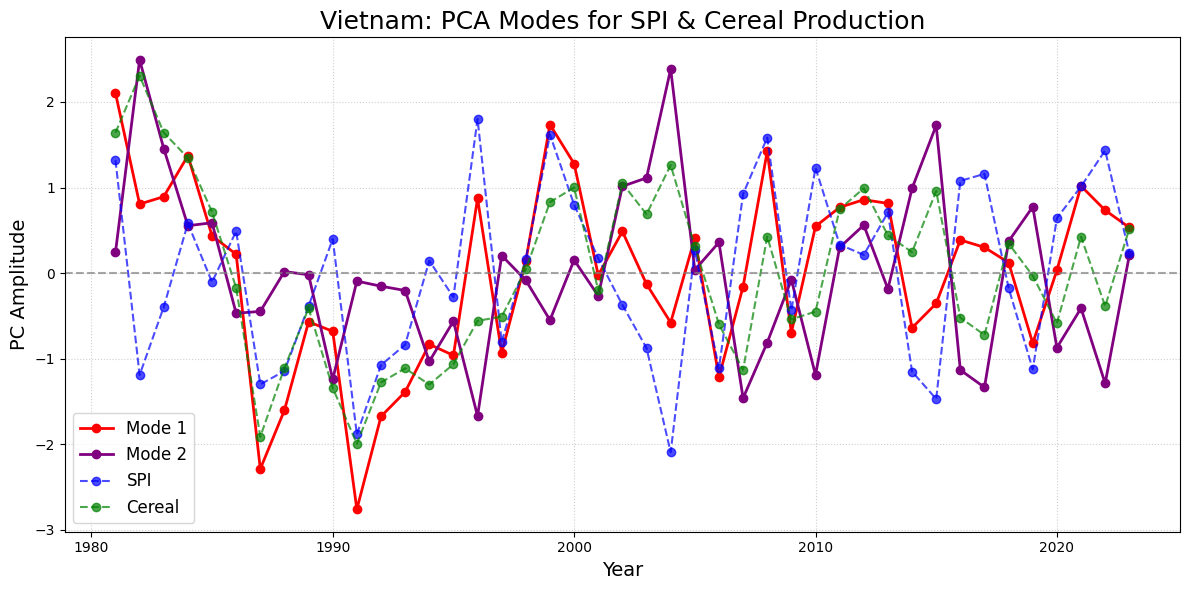

=== Indonesia PCA ===
Mode 1 Explained Variance: 63.97%
Mode 2 Explained Variance: 36.03%
(Note: Only 2 modes exist because only 2 input features were provided)



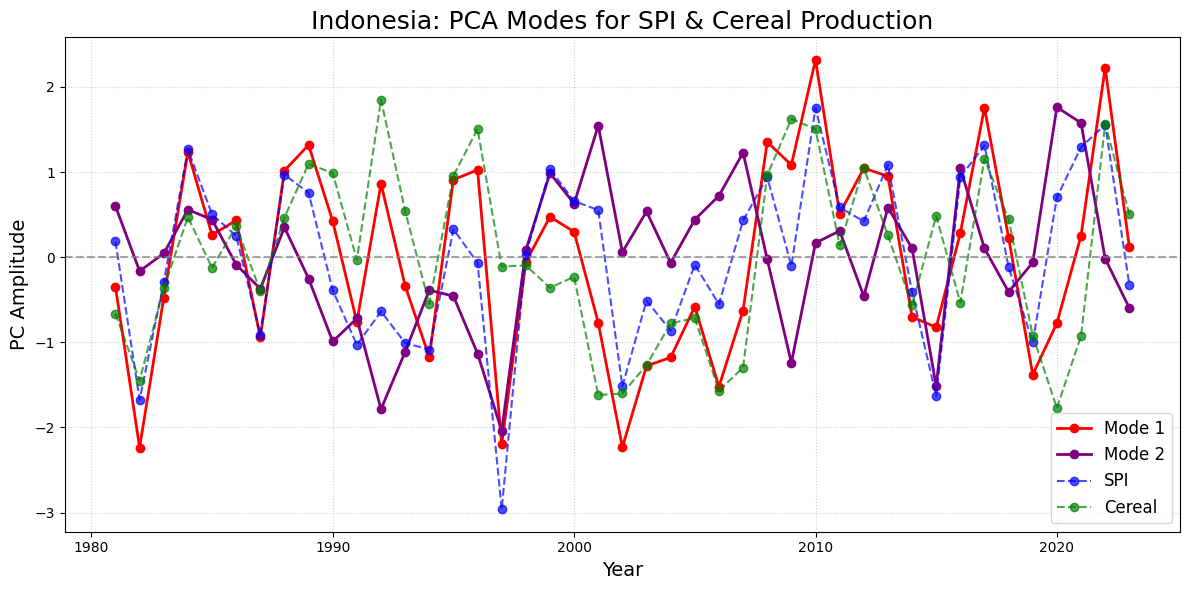

In [52]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def apply_pca_and_plot(df, country_name):
    # Drop NaNs to ensure PCA runs smoothly
    df_clean = df.dropna(subset=['spi', 'Anomaly_Normalized']).copy()

    # Select the features: SPI (using the best correlated, SPI-12) and Normalized Anomaly
    X = df_clean[['spi', 'Anomaly_Normalized']]

    # Standardize the features before applying PCA
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Fit PCA. Since we have 2 features, the maximum number of components is 2.
    n_components = min(3, X_scaled.shape[1])
    pca = PCA(n_components=n_components)
    pcs = pca.fit_transform(X_scaled)

    # Display explained variance
    print(f"=== {country_name} PCA ===")
    for i, ev in enumerate(pca.explained_variance_ratio_):
        print(f"Mode {i+1} Explained Variance: {ev*100:.2f}%")
    if n_components < 3:
        print(f"(Note: Only {n_components} modes exist because only 2 input features were provided)\n")

    pc_color = ['red', 'purple']
    # Plotting
    plt.figure(figsize=(12, 6))
    for i in range(n_components):
        plt.plot(df_clean['Year'], pcs[:, i], marker='o', linewidth=2, c=pc_color[i],
                 label=f'Mode {i+1}')

    plt.plot(df['Year'], df['spi'], label="SPI", marker='o', c="blue", alpha=0.7, linestyle='--')
    plt.plot(df['Year'], df['Anomaly_Normalized'], label="Cereal", marker='o', c="green", alpha=0.7, linestyle='--')


    plt.title(f'{country_name}: PCA Modes for SPI & Cereal Production', fontsize=18)
    plt.xlabel('Year', fontsize=14)
    plt.ylabel('PC Amplitude', fontsize=14)
    plt.axhline(0, color='gray', linestyle='--', alpha=0.7)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

# Apply to Vietnam
apply_pca_and_plot(merged_viet, "Vietnam")

# Apply to Indonesia
apply_pca_and_plot(merged_ind, "Indonesia")


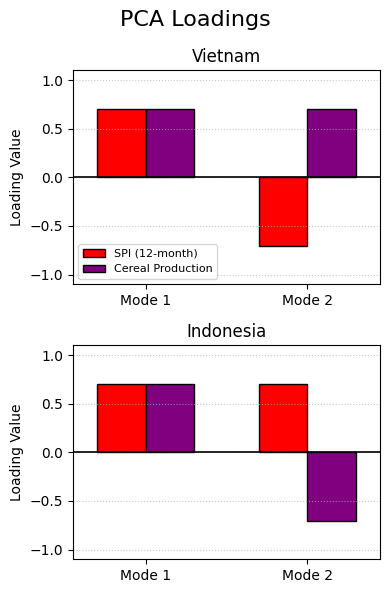

In [53]:
def get_pca_loadings(df):
    # Clean data and isolate features
    df_clean = df.dropna(subset=['spi', 'Anomaly_Normalized']).copy()
    features = ['spi', 'Anomaly_Normalized']
    X = df_clean[features]

    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Fit PCA
    pca = PCA(n_components=2)
    pca.fit(X_scaled)

    # Create a DataFrame for the loadings
    loadings = pd.DataFrame(
        pca.components_,
        columns=['SPI (12-month)', 'Cereal Production'],
        index=['Mode 1', 'Mode 2']
    )
    return loadings

loadings_viet = get_pca_loadings(merged_viet)
loadings_ind = get_pca_loadings(merged_ind)

pc_color = ['red', 'purple']

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(4, 6))

# Vietnam Subplot
loadings_viet.plot(kind='bar', ax=axes[0], rot=0, color=pc_color, edgecolor='black', width=0.6)
axes[0].set_title('Vietnam', fontsize=12)
axes[0].set_ylabel('Loading Value', fontsize=10)
axes[0].axhline(0, color='black', linestyle='-', linewidth=1.2)
axes[0].set_ylim(-1.1, 1.1)
axes[0].set_xlim(-0.45, 1.45)
axes[0].grid(axis='y', linestyle=':', alpha=0.7)
axes[0].legend(loc='lower left', fontsize=8)

# Indonesia Subplot
loadings_ind.plot(kind='bar', ax=axes[1], rot=0, color=pc_color, edgecolor='black', legend=False, width=0.6)
axes[1].set_title('Indonesia', fontsize=12)
axes[1].set_ylabel('Loading Value', fontsize=10)
axes[1].axhline(0, color='black', linestyle='-', linewidth=1.2)
axes[1].set_ylim(-1.1, 1.1)
axes[1].set_xlim(-0.45, 1.45)
axes[1].grid(axis='y', linestyle=':', alpha=0.7)

fig.suptitle('PCA Loadings', fontsize=16)
plt.tight_layout()
plt.show()


## Drought Event Return Period (EXTRA)
TODO: Derive return period of drought events by fitting GEV distribution to ranked SPI or raw precipitation values.

## Correlation with ENSO (EXTRA)